# Download the Dataset

In [1]:
import kagglehub
khanfashee_nih_chest_x_ray_14_224x224_resized_path = kagglehub.dataset_download('khanfashee/nih-chest-x-ray-14-224x224-resized')

print('Data source import complete.')

Data source import complete.


# Import Dependencies

In [2]:
import os
import random
import warnings

import cv2
import numpy as np
import pandas as pd
from PIL import Image
import albumentations as A
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.transforms as transforms
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim.lr_scheduler import LinearLR, SequentialLR, CosineAnnealingLR, ReduceLROnPlateau

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import seaborn as sns

import timm
from timm.data import create_transform

from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix

## Setup Reproducibility

In [3]:
def set_seed(seed=42):
    """
    Sets all seeds for reproducibility.
    """
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # For multi-GPU setups

    # Critical for CuDNN reproducibility
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    print(f"Seeds set to {seed} for reproducibility.")

set_seed(42)

# Plot defaults
sns.set_theme(style="whitegrid", context="notebook")

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],  # Sets the specific font
    'font.size': 17, 
    'axes.labelsize': 17, 
    'axes.titlesize': 20, 
    'legend.fontsize': 17, 
    'xtick.labelsize': 17, 
    'ytick.labelsize': 17
})

Seeds set to 42 for reproducibility.


## Set File Paths

In [4]:
# Define dataset paths for the Kaggle environment
DATA_DIR = khanfashee_nih_chest_x_ray_14_224x224_resized_path
CSV_PATH = os.path.join(DATA_DIR, 'Data_Entry_2017.csv')
IMAGE_DIR = os.path.join(DATA_DIR, 'images-224/images-224/')
BBOX_DIR = os.path.join(DATA_DIR, 'BBox_List_2017_Official_NIH.csv')

# 14 Pathology classes evaluated in ChestX-ray14
DISEASES = [
    'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion',
    'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'Nodule',
    'Pleural_Thickening', 'Pneumonia', 'Pneumothorax'
]

# Initialize Dataset

In [5]:
df = pd.read_csv(CSV_PATH)

# Add full image path for the PyTorch dataloader later
df['Image_Path'] = df['Image Index'].apply(lambda x: os.path.join(IMAGE_DIR, x))

print(f"Total records loaded: {len(df)}")

# Split the pipe-separated strings into lists, handling 'No Finding' as an empty list
df['Labels'] = df['Finding Labels'].apply(lambda x: x.split('|') if x != 'No Finding' else [])

# Initialize and fit the binarizer for the 14 specific diseases
mlb = MultiLabelBinarizer(classes=DISEASES)
encoded_labels = mlb.fit_transform(df['Labels'])

# Append encoded labels as new columns to the dataframe
for i, disease in enumerate(DISEASES):
    df[disease] = encoded_labels[:, i]


# Initialize GroupShuffleSplit for the first split (Hold out 20% for Testing)
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# 1. Split into (Train+Val) and Test
train_val_idx, test_idx = next(gss_test.split(df, groups=df['Patient ID']))
train_val_df = df.iloc[train_val_idx].reset_index(drop=True)
test_df = df.iloc[test_idx].reset_index(drop=True)

# Initialize a second GroupShuffleSplit for the Train/Val split
# Following the paper: 80% of the remaining data forms the training split
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# 2. Split (Train+Val) into Train and Validation
train_idx, val_idx = next(gss_val.split(train_val_df, groups=train_val_df['Patient ID']))
train_df = train_val_df.iloc[train_idx].reset_index(drop=True)
val_df = train_val_df.iloc[val_idx].reset_index(drop=True)

print(f"Total distinct patients: {df['Patient ID'].nunique()}")
print(f"Training images: {len(train_df)} ({(len(train_df)/len(df))*100:.1f}%)")
print(f"Validation images: {len(val_df)} ({(len(val_df)/len(df))*100:.1f}%)")
print(f"Testing images: {len(test_df)} ({(len(test_df)/len(df))*100:.1f}%)")

# Verify absolutely no patient overlap across any of the three sets
train_patients = set(train_df['Patient ID'])
val_patients = set(val_df['Patient ID'])
test_patients = set(test_df['Patient ID'])

assert len(train_patients.intersection(val_patients)) == 0, "Leakage: Train/Val overlap"
assert len(train_patients.intersection(test_patients)) == 0, "Leakage: Train/Test overlap"
assert len(val_patients.intersection(test_patients)) == 0, "Leakage: Val/Test overlap"

print("Verification passed: No patient overlap across Train, Validation, and Test sets.")

Total records loaded: 112120
Total distinct patients: 30805
Training images: 72061 (64.3%)
Validation images: 17765 (15.8%)
Testing images: 22294 (19.9%)
Verification passed: No patient overlap across Train, Validation, and Test sets.


In [6]:
class ChestXrayDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        """
        Args:
            dataframe (pd.DataFrame): The train or validation dataframe.
            transform (callable, optional): Transform pipeline (augmentation + resize + normalize).
                                            Pass train_transform for training, base_transform for val/test.
        """
        self.dataframe = dataframe
        self.transform = transform
        self.image_paths = dataframe['Image_Path'].values
        self.labels = dataframe[DISEASES].values

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        image = np.array(Image.open(self.image_paths[idx]).convert('RGB'))

        if self.transform:
            image = self.transform(image=image)["image"]

        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        return image, label
    
    
IMG_SIZE = 224
DATASET_MEAN = np.array([0.4982, 0.4982, 0.4982])
DATASET_STD = np.array([0.2484, 0.2484, 0.2484])

print("Building train, validation, and test transforms...")

# 1. Base transform (always applied): Resize + Normalize
base_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE, interpolation=cv2.INTER_CUBIC),
    A.Normalize(mean=DATASET_MEAN, std=DATASET_STD),
    ToTensorV2(),
])


# Define batch size
BATCH_SIZE = 64  # Warning: Consider lowering to 32/64 if CUDA Out of Memory occurs


# Validation dataset (no augmentation, just base transforms)
val_dataset = ChestXrayDataset(
    dataframe=val_df,
    transform=base_transform,                     # No augmentations
)
test_dataset = ChestXrayDataset(
    dataframe=test_df,
    transform=base_transform,                     # No augmentations
)

Building train, validation, and test transforms...


## Initialize DataLoaders

In [7]:
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,      # No need to shuffle test data
    num_workers=0,
    pin_memory=True
)

print(f"DataLoaders created. Batch size: {BATCH_SIZE}")
print(f"Validation batches: {len(val_loader)}")
print(f"Testing batches: {len(test_loader)}")

# Quick sanity check
sample_images, sample_labels = next(iter(test_loader))
print(f"Sample image batch shape: {sample_images.shape}")
print(f"Sample label batch shape: {sample_labels.shape}")

DataLoaders created. Batch size: 64
Validation batches: 278
Testing batches: 349
Sample image batch shape: torch.Size([64, 3, 224, 224])
Sample label batch shape: torch.Size([64, 14])


# Setup Model

In [8]:
class DenseCheX(nn.Module):
    def __init__(self, num_classes=14, model_name='densenet121'):
        super().__init__()
        # By passing num_classes=14, timm automatically drops the 1000-class
        # ImageNet head and replaces it with a single nn.Linear(1024, 14) layer.
        self.model = timm.create_model(
            model_name,
            pretrained=True,
            num_classes=num_classes
        )

    def forward(self, x):
        # Outputs raw logits for the 14 classes to be used with BCEWithLogitsLoss
        return self.model(x)
    
# Check hardware availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using compute device: {device}")
print(f"Number of GPUs available: {torch.cuda.device_count()}")

Using compute device: cuda
Number of GPUs available: 1


In [9]:
densenet = DenseCheX(num_classes=len(DISEASES), model_name='densenet121').to(device)
densenet.load_state_dict(torch.load('../weights/RANDOMSAMPLING.pth'))

efficientnet = DenseCheX(num_classes=len(DISEASES), model_name='efficientnetv2_rw_s.ra2_in1k').to(device)
efficientnet.load_state_dict(torch.load('../weights/EFFICIENTNET.pth'))

swin = DenseCheX(num_classes=len(DISEASES), model_name='swin_small_patch4_window7_224.ms_in22k').to(device)
swin.load_state_dict(torch.load('../weights/SWIN.pth'))

resnet = DenseCheX(num_classes=len(DISEASES), model_name='resnet50').to(device)
resnet.load_state_dict(torch.load('../weights/RESNET50.pth'))

<All keys matched successfully>

# Compare and Analyze models

In [10]:
def predict_model(model, data_loader, device, desc=None):
    all_preds = []
    all_labels = []
    model.eval()

    with torch.no_grad():
        for images, labels in tqdm(data_loader, desc=desc):
            images = images.to(device)

            probs = torch.sigmoid(model(images))      # [1, 14]

            all_preds.append(probs.cpu().numpy())
            all_labels.append(labels.numpy())

    preds = np.vstack(all_preds)
    labels = np.vstack(all_labels)
    
    return preds, labels

## Calculate Metrics

In [11]:
from sklearn.metrics import (roc_auc_score, f1_score, confusion_matrix,
                             average_precision_score)

def _bootstrap_ci(true_labels, pred_probs, metric_fn, n_boot=1000, ci=0.95, seed=42):
    rng = np.random.default_rng(seed)
    n = len(true_labels)
    scores = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        bt, bp = true_labels[idx], pred_probs[idx]
        if len(np.unique(bt)) < 2:
            continue
        try:
            scores.append(metric_fn(bt, bp))
        except ValueError:
            continue
    if not scores:
        return (np.nan, np.nan)
    alpha = (1 - ci) / 2
    return (np.percentile(scores, 100 * alpha),
            np.percentile(scores, 100 * (1 - alpha)))


def _expected_calibration_error(true_labels, pred_probs, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    n = len(true_labels)
    for i in range(n_bins):
        mask = (pred_probs >= bins[i]) & (pred_probs < bins[i + 1])
        if mask.sum() == 0:
            continue
        ece += (mask.sum() / n) * abs(true_labels[mask].mean() - pred_probs[mask].mean())
    return ece


def evaluate_metrics(preds, labels, diseases, n_boot=1000, raw=False):
    results = []

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")

        for i, disease in enumerate(diseases):
            true_labels = labels[:, i]
            pred_probs  = preds[:, i]

            # --- AUROC + AUPRC ---
            try:
                auc = roc_auc_score(true_labels, pred_probs)
            except ValueError:
                auc = np.nan

            try:
                auprc = average_precision_score(true_labels, pred_probs)
            except ValueError:
                auprc = np.nan

            # --- Bootstrap CIs ---
            auroc_ci = _bootstrap_ci(true_labels, pred_probs, roc_auc_score,  n_boot=n_boot)
            auprc_ci = _bootstrap_ci(true_labels, pred_probs, average_precision_score, n_boot=n_boot)

            # --- Calibration ---
            ece = _expected_calibration_error(true_labels, pred_probs)

            # --- Threshold optimization (binary F1) ---
            thresholds = np.linspace(0.01, 0.9, 181)
            best_f1, best_thresh = 0.0, 0.5
            best_metrics = {'Sens': 0.0, 'Spec': 0.0, 'Prec': 0.0}

            for thresh in thresholds:
                pred_binary = (pred_probs >= thresh).astype(int)
                f1 = f1_score(true_labels, pred_binary, average='macro', zero_division=0)
                if f1 > best_f1:
                    best_f1 = f1
                    best_thresh = thresh
                    tn, fp, fn, tp = confusion_matrix(true_labels, pred_binary, labels=[0, 1]).ravel()
                    best_metrics['Sens'] = tp / (tp + fn) if (tp + fn) > 0 else 0.0
                    best_metrics['Spec'] = tn / (tn + fp) if (tn + fp) > 0 else 0.0
                    best_metrics['Prec'] = tp / (tp + fp) if (tp + fp) > 0 else 0.0

            results.append({
                'Pathology':    disease,
                'Threshold':    best_thresh,
                'AUROC':        auc,
                'AUROC_CI':     f'[{auroc_ci[0]:.3f}, {auroc_ci[1]:.3f}]' if not np.isnan(auc) else 'N/A',
                'AUPRC':        auprc,
                'AUPRC_CI':     f'[{auprc_ci[0]:.3f}, {auprc_ci[1]:.3f}]' if not np.isnan(auprc) else 'N/A',
                'ECE':          ece,
                'F1':           best_f1,
                'Sensitivity':  best_metrics['Sens'],
                'Specificity':  best_metrics['Spec'],
                'Precision':    best_metrics['Prec'],
            })

    results_df = pd.DataFrame(results)

    mean_values = results_df.select_dtypes(include=[np.number]).mean()
    mean_row = pd.DataFrame([{'Pathology': 'MACRO AVG', **mean_values}])
    results_df = pd.concat([results_df, mean_row], ignore_index=True)
    
    if raw == True:
        return results_df

    fmt = {
        'Threshold': '{:.2f}', 'AUROC': '{:.3f}', 'AUPRC': '{:.3f}',
        'ECE': '{:.3f}', 'F1': '{:.3f}',
        'Sensitivity': '{:.3f}', 'Specificity': '{:.3f}', 'Precision': '{:.3f}'
    }
    for col, f in fmt.items():
        results_df[col] = results_df[col].map(lambda x: f.format(x) if pd.notna(x) else 'N/A')

    return results_df

In [12]:
densenet_results = evaluate_metrics(*predict_model(densenet, test_loader, device, "DenseNet Model Inference"), DISEASES)
efficientnet_results = evaluate_metrics(*predict_model(efficientnet, test_loader, device, "EfficientNet Model Inference"), DISEASES)
swin_results = evaluate_metrics(*predict_model(swin, test_loader, device, "Swin Model Inference"), DISEASES)
resnet_results = evaluate_metrics(*predict_model(resnet, test_loader, device, "Resnet Model Inference"), DISEASES)

DenseNet Model Inference:   0%|          | 0/349 [00:00<?, ?it/s]

EfficientNet Model Inference:   0%|          | 0/349 [00:00<?, ?it/s]

Swin Model Inference:   0%|          | 0/349 [00:00<?, ?it/s]

Resnet Model Inference:   0%|          | 0/349 [00:00<?, ?it/s]

In [13]:
display(densenet_results)
display(efficientnet_results)
display(swin_results)
display(resnet_results)

,Pathology,Threshold,AUROC,AUROC_CI,AUPRC,AUPRC_CI,ECE,F1,Sensitivity,Specificity,Precision
0,Atelectasis,0.26,0.814,"[0.805, 0.822]",0.355,"[0.336, 0.377]",0.017,0.663,0.453,0.912,0.359
1,Cardiomegaly,0.22,0.922,"[0.912, 0.931]",0.316,"[0.280, 0.354]",0.007,0.687,0.494,0.972,0.331
2,Consolidation,0.16,0.814,"[0.801, 0.827]",0.166,"[0.149, 0.188]",0.006,0.603,0.348,0.937,0.197
3,Edema,0.25,0.892,"[0.878, 0.907]",0.165,"[0.142, 0.197]",0.010,0.613,0.315,0.974,0.201
4,Effusion,0.30,0.878,"[0.872, 0.885]",0.505,"[0.484, 0.525]",0.016,0.730,0.602,0.914,0.474
5,Emphysema,0.16,0.901,"[0.885, 0.916]",0.315,"[0.277, 0.358]",0.006,0.706,0.482,0.981,0.385
6,Fibrosis,0.06,0.801,"[0.777, 0.823]",0.101,"[0.080, 0.130]",0.006,0.572,0.288,0.965,0.119
7,Hernia,0.31,0.922,"[0.884, 0.959]",0.330,"[0.187, 0.482]",0.001,0.720,0.354,0.999,0.586
8,Infiltration,0.26,0.710,"[0.701, 0.719]",0.351,"[0.337, 0.366]",0.025,0.630,0.435,0.841,0.381
9,Mass,0.31,0.846,"[0.832, 0.857]",0.311,"[0.285, 0.341]",0.015,0.670,0.362,0.971,0.382


,Pathology,Threshold,AUROC,AUROC_CI,AUPRC,AUPRC_CI,ECE,F1,Sensitivity,Specificity,Precision
0,Atelectasis,0.24,0.816,"[0.807, 0.825]",0.363,"[0.345, 0.384]",0.012,0.665,0.469,0.908,0.358
1,Cardiomegaly,0.16,0.909,"[0.899, 0.918]",0.288,"[0.255, 0.324]",0.009,0.680,0.424,0.977,0.345
2,Consolidation,0.10,0.820,"[0.806, 0.833]",0.167,"[0.150, 0.187]",0.012,0.596,0.403,0.918,0.180
3,Edema,0.09,0.884,"[0.869, 0.899]",0.150,"[0.126, 0.180]",0.006,0.602,0.474,0.947,0.158
4,Effusion,0.24,0.874,"[0.867, 0.881]",0.491,"[0.471, 0.512]",0.024,0.728,0.590,0.915,0.474
5,Emphysema,0.17,0.911,"[0.897, 0.923]",0.341,"[0.302, 0.386]",0.008,0.708,0.452,0.984,0.410
6,Fibrosis,0.10,0.802,"[0.777, 0.823]",0.097,"[0.077, 0.126]",0.006,0.574,0.184,0.982,0.146
7,Hernia,0.08,0.915,"[0.868, 0.952]",0.288,"[0.143, 0.446]",0.001,0.711,0.312,1.000,0.652
8,Infiltration,0.26,0.714,"[0.706, 0.723]",0.348,"[0.334, 0.363]",0.028,0.633,0.417,0.855,0.393
9,Mass,0.16,0.839,"[0.825, 0.851]",0.315,"[0.290, 0.344]",0.015,0.671,0.403,0.963,0.353


,Pathology,Threshold,AUROC,AUROC_CI,AUPRC,AUPRC_CI,ECE,F1,Sensitivity,Specificity,Precision
0,Atelectasis,0.28,0.812,"[0.804, 0.821]",0.341,"[0.323, 0.362]",0.013,0.658,0.407,0.924,0.370
1,Cardiomegaly,0.26,0.924,"[0.915, 0.932]",0.322,"[0.284, 0.358]",0.007,0.695,0.448,0.979,0.377
2,Consolidation,0.14,0.819,"[0.806, 0.832]",0.165,"[0.148, 0.184]",0.005,0.603,0.354,0.935,0.197
3,Edema,0.20,0.891,"[0.877, 0.904]",0.162,"[0.139, 0.190]",0.006,0.615,0.293,0.978,0.215
4,Effusion,0.35,0.881,"[0.875, 0.887]",0.507,"[0.487, 0.528]",0.017,0.729,0.549,0.929,0.500
5,Emphysema,0.17,0.913,"[0.900, 0.926]",0.346,"[0.308, 0.390]",0.006,0.713,0.492,0.982,0.399
6,Fibrosis,0.12,0.807,"[0.783, 0.829]",0.098,"[0.078, 0.131]",0.004,0.576,0.168,0.986,0.164
7,Hernia,0.12,0.875,"[0.822, 0.924]",0.056,"[0.021, 0.143]",0.000,0.558,0.083,0.999,0.200
8,Infiltration,0.28,0.714,"[0.706, 0.722]",0.358,"[0.344, 0.373]",0.016,0.635,0.435,0.848,0.391
9,Mass,0.14,0.840,"[0.828, 0.853]",0.306,"[0.278, 0.336]",0.013,0.666,0.481,0.945,0.306


,Pathology,Threshold,AUROC,AUROC_CI,AUPRC,AUPRC_CI,ECE,F1,Sensitivity,Specificity,Precision
0,Atelectasis,0.26,0.811,"[0.802, 0.820]",0.347,"[0.327, 0.368]",0.016,0.656,0.417,0.918,0.357
1,Cardiomegaly,0.16,0.912,"[0.900, 0.922]",0.320,"[0.285, 0.358]",0.008,0.688,0.443,0.977,0.358
2,Consolidation,0.13,0.815,"[0.801, 0.827]",0.160,"[0.144, 0.179]",0.012,0.601,0.318,0.943,0.200
3,Edema,0.11,0.889,"[0.874, 0.902]",0.163,"[0.138, 0.195]",0.005,0.613,0.388,0.965,0.185
4,Effusion,0.29,0.879,"[0.873, 0.886]",0.500,"[0.480, 0.520]",0.018,0.728,0.566,0.923,0.487
5,Emphysema,0.11,0.916,"[0.903, 0.929]",0.341,"[0.300, 0.386]",0.008,0.708,0.527,0.978,0.368
6,Fibrosis,0.12,0.800,"[0.776, 0.822]",0.099,"[0.079, 0.127]",0.003,0.584,0.195,0.984,0.172
7,Hernia,0.11,0.896,"[0.839, 0.950]",0.149,"[0.067, 0.286]",0.001,0.621,0.167,1.000,0.444
8,Infiltration,0.24,0.708,"[0.700, 0.717]",0.350,"[0.337, 0.365]",0.045,0.633,0.427,0.849,0.388
9,Mass,0.24,0.836,"[0.823, 0.849]",0.287,"[0.263, 0.314]",0.011,0.667,0.399,0.961,0.342


## Compare Results

In [14]:
def to_numeric_df(results_df):
    df = results_df.copy()
    # Drop the CI columns (they're strings like "[0.805, 0.822]")
    df = df.drop(columns=['AUROC_CI', 'AUPRC_CI'], errors='ignore')
    # Convert everything except Pathology to numeric
    numeric_cols = [c for c in df.columns if c != 'Pathology']
    df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')
    return df

densenet_num   = to_numeric_df(densenet_results)
efficientnet_num = to_numeric_df(efficientnet_results)
swin_num = to_numeric_df(swin_results)
resnet_num = to_numeric_df(resnet_results)

In [15]:
densenet_preds,   densenet_labels   = predict_model(densenet,   test_loader, device, "DenseNet")
efficientnet_preds, efficientnet_labels = predict_model(efficientnet,  test_loader, device, "EfficientNet")
swin_preds, swin_labels = predict_model(swin,  test_loader, device, "Swin")
resnet_preds, resnet_labels = predict_model(resnet,  test_loader, device, "Resnet")


# All label arrays should be identical — sanity check
assert np.array_equal(densenet_labels, efficientnet_labels)
assert np.array_equal(densenet_labels, swin_labels)
assert np.array_equal(densenet_labels, resnet_labels)

labels = densenet_labels  # one ground truth for all models

DenseNet:   0%|          | 0/349 [00:00<?, ?it/s]

EfficientNet:   0%|          | 0/349 [00:00<?, ?it/s]

Swin:   0%|          | 0/349 [00:00<?, ?it/s]

Resnet:   0%|          | 0/349 [00:00<?, ?it/s]

In [16]:
model_results = {
    'DenseNet':   densenet_num,
    'EfficientNet': efficientnet_num,
    'Swin': swin_num,
    'Resnet': resnet_num
}

def build_comparison(model_results, metric='AUROC'):
    rows = []
    for model_name, df in model_results.items():
        # exclude MACRO AVG row for per-label comparison
        per_label = df[df['Pathology'] != 'MACRO AVG'].set_index('Pathology')
        rows.append(per_label[metric].rename(model_name))
    
    comp = pd.concat(rows, axis=1)
    
    # add a best-model column
    comp['Best'] = comp.idxmax(axis=1)
    
    # add macro average row
    macro = {name: df.loc[df['Pathology'] == 'MACRO AVG', metric].values[0]
             for name, df in model_results.items()}
    macro['Best'] = max(macro, key=lambda k: macro[k])
    comp.loc['MACRO AVG'] = macro
    
    return comp

auroc_comp = build_comparison(model_results, 'AUROC')
auprc_comp = build_comparison(model_results, 'AUPRC')
f1_comp    = build_comparison(model_results, 'F1')

print(auroc_comp.to_string())

                    DenseNet  EfficientNet   Swin  Resnet          Best
Pathology                                                              
Atelectasis            0.814         0.816  0.812   0.811  EfficientNet
Cardiomegaly           0.922         0.909  0.924   0.912          Swin
Consolidation          0.814         0.820  0.819   0.815  EfficientNet
Edema                  0.892         0.884  0.891   0.889      DenseNet
Effusion               0.878         0.874  0.881   0.879          Swin
Emphysema              0.901         0.911  0.913   0.916        Resnet
Fibrosis               0.801         0.802  0.807   0.800          Swin
Hernia                 0.922         0.915  0.875   0.896      DenseNet
Infiltration           0.710         0.714  0.714   0.708  EfficientNet
Mass                   0.846         0.839  0.840   0.836      DenseNet
Nodule                 0.750         0.776  0.744   0.742  EfficientNet
Pleural_Thickening     0.801         0.799  0.787   0.792      D

In [17]:
from itertools import combinations
from scipy.stats import norm

def delong_test(y_true, prob_a, prob_b):
    def auc_components(y, p):
        pos, neg = p[y == 1], p[y == 0]
        v10 = np.array([np.mean(pi > neg) + 0.5 * np.mean(pi == neg) for pi in pos])
        v01 = np.array([np.mean(pos > nj) + 0.5 * np.mean(pos == nj) for nj in neg])
        auc = v10.mean()
        var = np.var(v10, ddof=1) / len(pos) + np.var(v01, ddof=1) / len(neg)
        return auc, var

    auc_a, var_a = auc_components(y_true, prob_a)
    auc_b, var_b = auc_components(y_true, prob_b)
    se = np.sqrt(var_a + var_b)
    z  = (auc_a - auc_b) / se if se > 0 else 0.0
    p  = 2 * (1 - norm.cdf(abs(z)))
    return auc_a - auc_b, p

def compare_all_pairs(preds_dict, labels, diseases):
    model_names = list(preds_dict.keys())
    pairs = list(combinations(model_names, 2))
    records = []

    for disease_idx, disease in enumerate(diseases):
        y_true = labels[:, disease_idx]
        for (m1, m2) in pairs:
            diff, p = delong_test(
                y_true,
                preds_dict[m1][:, disease_idx],
                preds_dict[m2][:, disease_idx]
            )
            records.append({
                'Pathology': disease,
                'Model A':   m1,
                'Model B':   m2,
                'Pair':      f'{m1} vs {m2}',
                'AUC diff':  diff,
                'p_raw':     p,
            })

    df = pd.DataFrame(records)
    
    # Benjamini-Hochberg correction across all tests
    from statsmodels.stats.multitest import multipletests
    _, p_corrected, _, _ = multipletests(df['p_raw'], method='fdr_bh')
    df['p_corrected'] = p_corrected
    df['significant'] = df['p_corrected'] < 0.05
    
    return df

preds_dict = {
    'DenseNet':   densenet_preds,
    'EfficientNet': efficientnet_preds,
    'Swin': swin_preds,
    'Resnet': resnet_preds
}

delong_results = compare_all_pairs(preds_dict, labels, DISEASES)

# Quick summary: how many labels does each pair differ significantly on?
print(delong_results.groupby('Pair')['significant'].sum())

Pair
DenseNet vs EfficientNet    0
DenseNet vs Resnet          0
DenseNet vs Swin            0
EfficientNet vs Resnet      0
EfficientNet vs Swin        0
Swin vs Resnet              0
Name: significant, dtype: int64


In [18]:
delong_results[delong_results['significant']].sort_values('p_corrected')

,Pathology,Model A,Model B,Pair,AUC diff,p_raw,p_corrected,significant


## Analyze Metadata results

In [19]:
# Assuming you have metadata aligned with your test set
def subgroup_auroc(preds, labels, diseases, group_mask):
    sub_preds  = preds[group_mask]
    sub_labels = labels[group_mask]
    return evaluate_metrics(sub_preds, sub_labels, diseases, raw=True)


test_df['Patient Age'] = test_df['Patient Age'].str.extract(r'(\d+)').astype(int)

male_mask   = test_df['Patient Gender'] == 'M'
female_mask = test_df['Patient Gender'] == 'F'
young_mask  = test_df['Patient Age'] < 40
old_mask    = test_df['Patient Age'] >= 60

print("Evaluating male results")
male_results   = subgroup_auroc(efficientnet_preds, labels, DISEASES, male_mask)
print("Evaluating female results")
female_results = subgroup_auroc(efficientnet_preds, labels, DISEASES, female_mask)
print("Evaluating young results")
young_results  = subgroup_auroc(efficientnet_preds, labels, DISEASES, young_mask)
print("Evaluating old results")
old_results    = subgroup_auroc(efficientnet_preds, labels, DISEASES, old_mask)

Evaluating male results
Evaluating female results
Evaluating young results
Evaluating old results


# Visualizations

## Visualize SubGroups

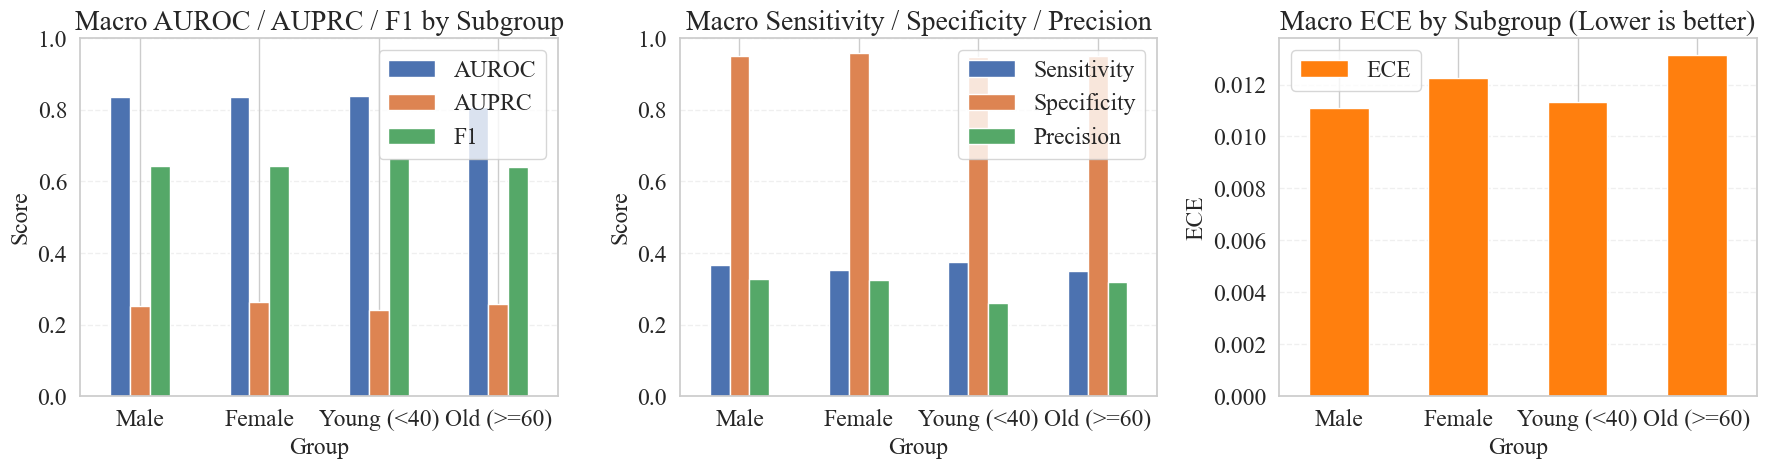

In [20]:
# Visualize subgroup performance (Male, Female, Young, Old)
subgroup_results = {
    'Male': male_results.copy(),
    'Female': female_results.copy(),
    'Young (<40)': young_results.copy(),
    'Old (>=60)': old_results.copy()
}

metrics = ['AUROC', 'AUPRC', 'F1', 'Sensitivity', 'Specificity', 'Precision', 'ECE']

# Ensure numeric dtype for plotting
for group_name, df_group in subgroup_results.items():
    for col in metrics:
        if col in df_group.columns:
            df_group[col] = pd.to_numeric(df_group[col], errors='coerce')

# 1) Macro-average comparison bar chart
macro_rows = []
for group_name, df_group in subgroup_results.items():
    macro_row = df_group[df_group['Pathology'] == 'MACRO AVG']
    if len(macro_row) == 1:
        row = {'Group': group_name}
        for m in metrics:
            row[m] = macro_row.iloc[0][m] if m in macro_row.columns else np.nan
        macro_rows.append(row)

macro_df = pd.DataFrame(macro_rows).set_index('Group')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

macro_df[['AUROC', 'AUPRC', 'F1']].plot(kind='bar', ax=axes[0], rot=0)
axes[0].set_title('Macro AUROC / AUPRC / F1 by Subgroup')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1)
axes[0].grid(axis='y', linestyle='--', alpha=0.3)

macro_df[['Sensitivity', 'Specificity', 'Precision']].plot(kind='bar', ax=axes[1], rot=0)
axes[1].set_title('Macro Sensitivity / Specificity / Precision')
axes[1].set_ylabel('Score')
axes[1].set_ylim(0, 1)
axes[1].grid(axis='y', linestyle='--', alpha=0.3)

macro_df[['ECE']].plot(kind='bar', ax=axes[2], rot=0, color=['#ff7f0e'])
axes[2].set_title('Macro ECE by Subgroup (Lower is better)')
axes[2].set_ylabel('ECE')
axes[2].grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

## Visualize Calibiration

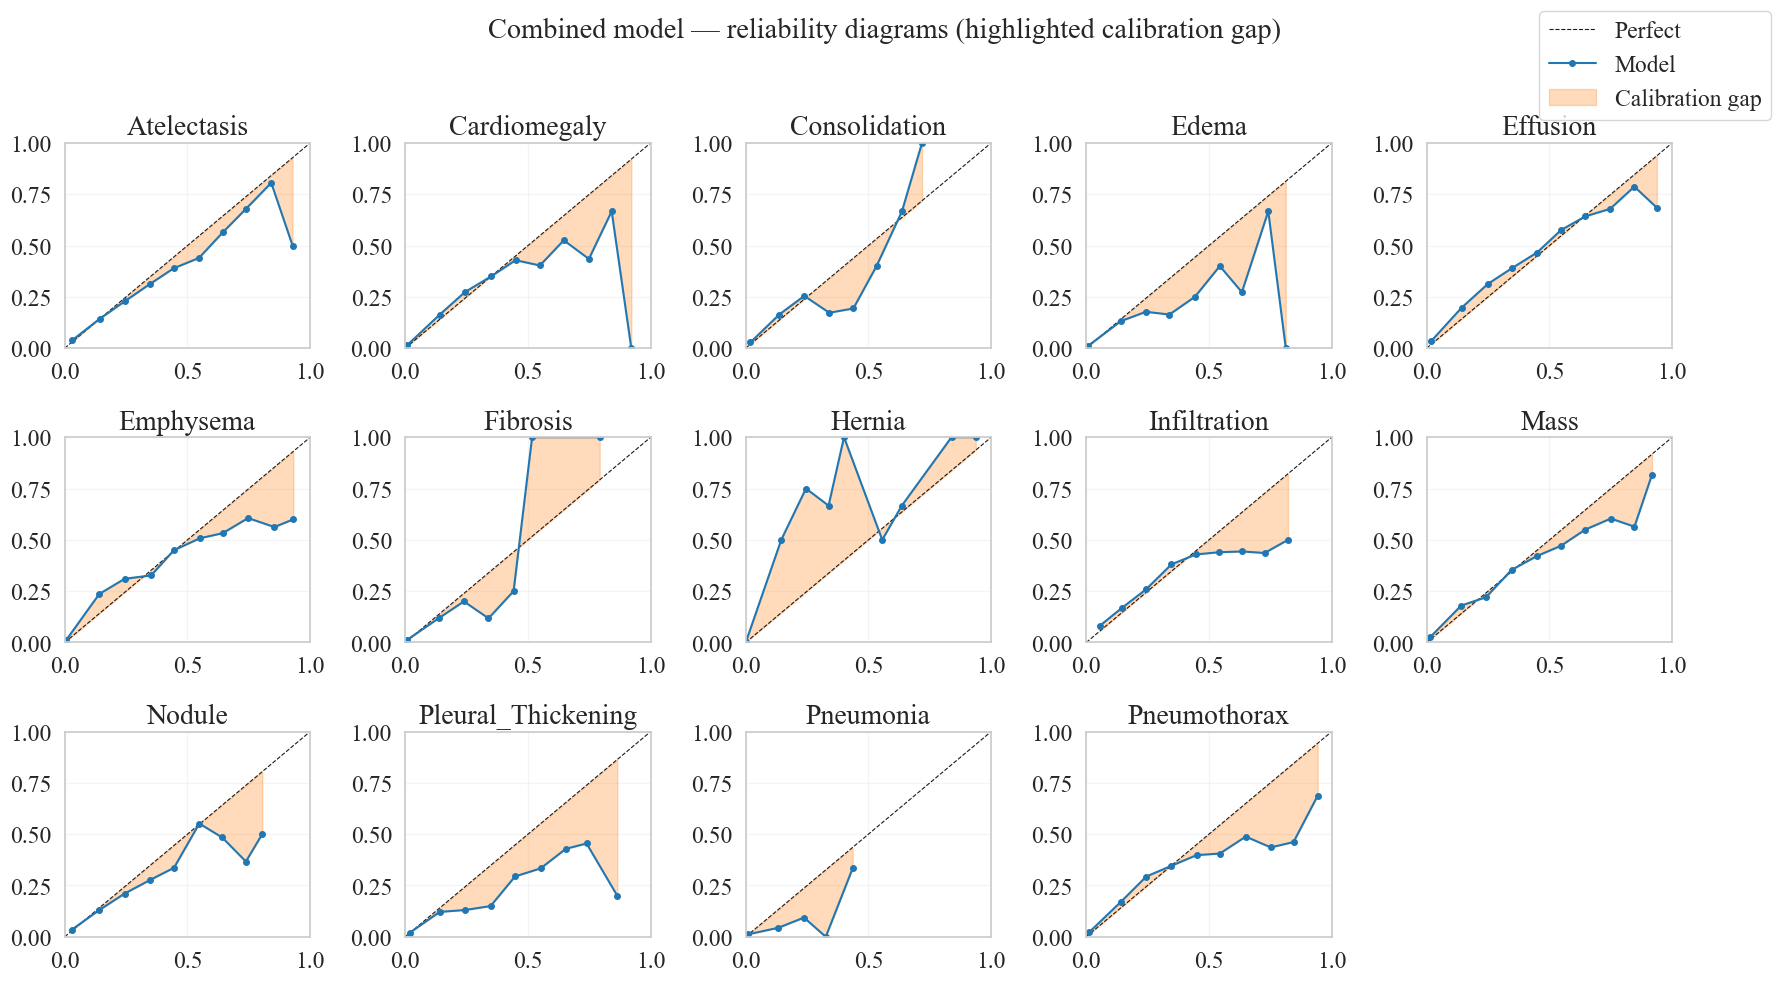

In [21]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(3, 5, figsize=(18, 10))
axes = axes.flatten()

for i, disease in enumerate(DISEASES):
    prob_true, prob_pred = calibration_curve(
        labels[:, i], efficientnet_preds[:, i], n_bins=10, strategy='uniform'
    )

    perfect_line = prob_pred

    axes[i].plot([0, 1], [0, 1], 'k--', lw=0.8, label='Perfect')
    axes[i].plot(prob_pred, prob_true, marker='o', markersize=4, color='tab:blue', label='Model')

    # Highlight calibration error area
    axes[i].fill_between(
        prob_pred,
        prob_true,
        perfect_line,
        color='tab:orange',
        alpha=0.28,
        label='Calibration gap'
    )

    axes[i].set_title(disease)
    axes[i].set_xlim(0, 1)
    axes[i].set_ylim(0, 1)
    axes[i].grid(alpha=0.2)

# Hide any unused subplot(s)
for j in range(len(DISEASES), len(axes)):
    axes[j].axis('off')

# Single legend for cleaner layout
handles, labels_legend = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_legend, loc='upper right')

plt.suptitle('Combined model — reliability diagrams (highlighted calibration gap)')
plt.tight_layout(rect=[0, 0, 0.96, 0.96])
# plt.savefig('calibration_combined.png', dpi=150)
plt.show()

# GradCAM visualizations

## Load Images

In [43]:
# -----------------------------
# 1) Load bbox metadata (clean)
# -----------------------------
bbox_df = pd.read_csv(BBOX_DIR)
bbox_df.columns = [c.strip() for c in bbox_df.columns]

# NIH columns are typically: Image Index, Finding Label, Bbox [x, y, w, h]
possible_map = {
    'Image Index': ['Image Index'],
    'Finding Label': ['Finding Label', 'Label'],
    'x': ['Bbox [x', 'x'],
    'y': ['y'],
    'w': ['w', 'width'],
    'h': ['h', 'height']
}

resolved = {}
for out_col, candidates in possible_map.items():
    found = None
    for c in candidates:
        if c in bbox_df.columns:
            found = c
            break
    if found is None:
        for col in bbox_df.columns:
            if any(c.lower() in col.lower() for c in candidates):
                found = col
                break
    if found is None:
        raise ValueError(f'Missing required bbox column for {out_col}. Available: {bbox_df.columns.tolist()}')
    resolved[out_col] = found

bbox_df = bbox_df[[resolved['Image Index'], resolved['Finding Label'], resolved['x'], resolved['y'], resolved['w'], resolved['h']]].rename(columns={
    resolved['Image Index']: 'Image Index',
    resolved['Finding Label']: 'Finding Label',
    resolved['x']: 'x',
    resolved['y']: 'y',
    resolved['w']: 'w',
    resolved['h']: 'h'
})

for c in ['x', 'y', 'w', 'h']:
    bbox_df[c] = pd.to_numeric(bbox_df[c], errors='coerce')
bbox_df = bbox_df.dropna(subset=['x', 'y', 'w', 'h']).copy()
bbox_df['Image Index'] = bbox_df['Image Index'].astype(str)
bbox_df['Finding Label'] = bbox_df['Finding Label'].astype(str)

# -----------------------------
# 2) Pick at least 8 images (unique Image Index), prioritizing label diversity
# -----------------------------
N_IMAGES = 12

# Use validation + test pools for analysis images
combined_eval_df = pd.concat([val_df, test_df], ignore_index=True)
test_name_to_path = dict(zip(combined_eval_df['Image Index'].astype(str), combined_eval_df['Image_Path']))
test_name_set = set(test_name_to_path.keys())

candidate_bbox = bbox_df[
    bbox_df['Image Index'].isin(test_name_set) &
    bbox_df['Finding Label'].isin(DISEASES)
].copy()

# Keep one bbox per image first
one_bbox_per_image = candidate_bbox.drop_duplicates(subset=['Image Index'], keep='first').copy()

# Take one image per label first, then fill remaining slots with any unused images
label_diverse = one_bbox_per_image.drop_duplicates(subset=['Finding Label'], keep='first').copy()

if len(label_diverse) >= N_IMAGES:
    selected_df = label_diverse.head(N_IMAGES).reset_index(drop=True)
else:
    used_images = set(label_diverse['Image Index'])
    fill_df = one_bbox_per_image[~one_bbox_per_image['Image Index'].isin(used_images)]
    needed = N_IMAGES - len(label_diverse)
    selected_df = pd.concat([label_diverse, fill_df.head(needed)], ignore_index=True)

if len(selected_df) < N_IMAGES:
    raise ValueError(
        f'Could only find {len(selected_df)} valid images in val+test with bbox and disease labels; expected at least {N_IMAGES}.'
    )

display(selected_df[['Image Index', 'Finding Label', 'x', 'y', 'w', 'h']])

,Image Index,Finding Label,x,y,w,h
0,00012515_002.png,Atelectasis,289.084746,638.137861,83.525424,56.406780
1,00009608_024.png,Cardiomegaly,394.305085,402.748030,365.559322,341.694915
2,00010828_039.png,Effusion,702.577778,447.469045,238.933333,237.795556
3,00010125_004.png,Mass,147.342222,301.833490,65.991111,87.608889
4,00004547_003.png,Nodule,899.386243,690.251852,53.096296,58.514286
5,00018393_000.png,Pneumonia,613.831111,466.811267,160.426667,201.386667
6,00030162_026.png,Pneumothorax,539.875556,268.837934,94.435556,73.955556
7,00022098_006.png,Atelectasis,494.101695,577.392098,271.186441,154.033898
8,00030674_000.png,Atelectasis,632.949153,251.968369,227.796610,210.440678
9,00006621_004.png,Atelectasis,307.525424,401.663285,214.779661,214.779661


## Perform GradCAM

In [44]:
# -----------------------------
# 3) Setup Grad-CAM (ready library)
# -----------------------------
efficientnet.eval()

last_conv_name = None
last_conv_layer = None
for name, module in reversed(list(efficientnet.model.named_modules())):
    if isinstance(module, nn.Conv2d):
        last_conv_name = name
        last_conv_layer = module
        break

if last_conv_layer is None:
    raise RuntimeError('No Conv2D layer found for Grad-CAM target.')

print(f'Grad-CAM target layer: {last_conv_name}')
cam_extractor = GradCAM(model=efficientnet, target_layers=[last_conv_layer])

Grad-CAM target layer: conv_head


## Grad-CAM + Single Bounding Box Visualization

,Image Index,Finding Label,inside_ratio,peak_inside,pred_prob
0,00012670_000.png,Cardiomegaly,0.435727,True,0.253267
1,00026753_008.png,Effusion,0.522620,True,0.824297
2,00018623_001.png,Mass,0.481897,True,0.543106
3,00002980_000.png,Pneumonia,0.552249,True,0.072371
4,00004342_023.png,Cardiomegaly,0.380599,True,0.351840
5,00021967_000.png,Effusion,0.388811,True,0.069287
6,00021179_011.png,Mass,0.504905,True,0.760021
7,00008291_009.png,Pneumonia,0.887898,True,0.051387
8,00013125_000.png,Cardiomegaly,0.442044,True,0.066219
9,00029588_004.png,Effusion,0.249482,False,0.512801


Class distribution in selected examples:
Finding Label
Cardiomegaly    3
Effusion        3
Pneumonia       3
Mass            2
Name: count, dtype: int64


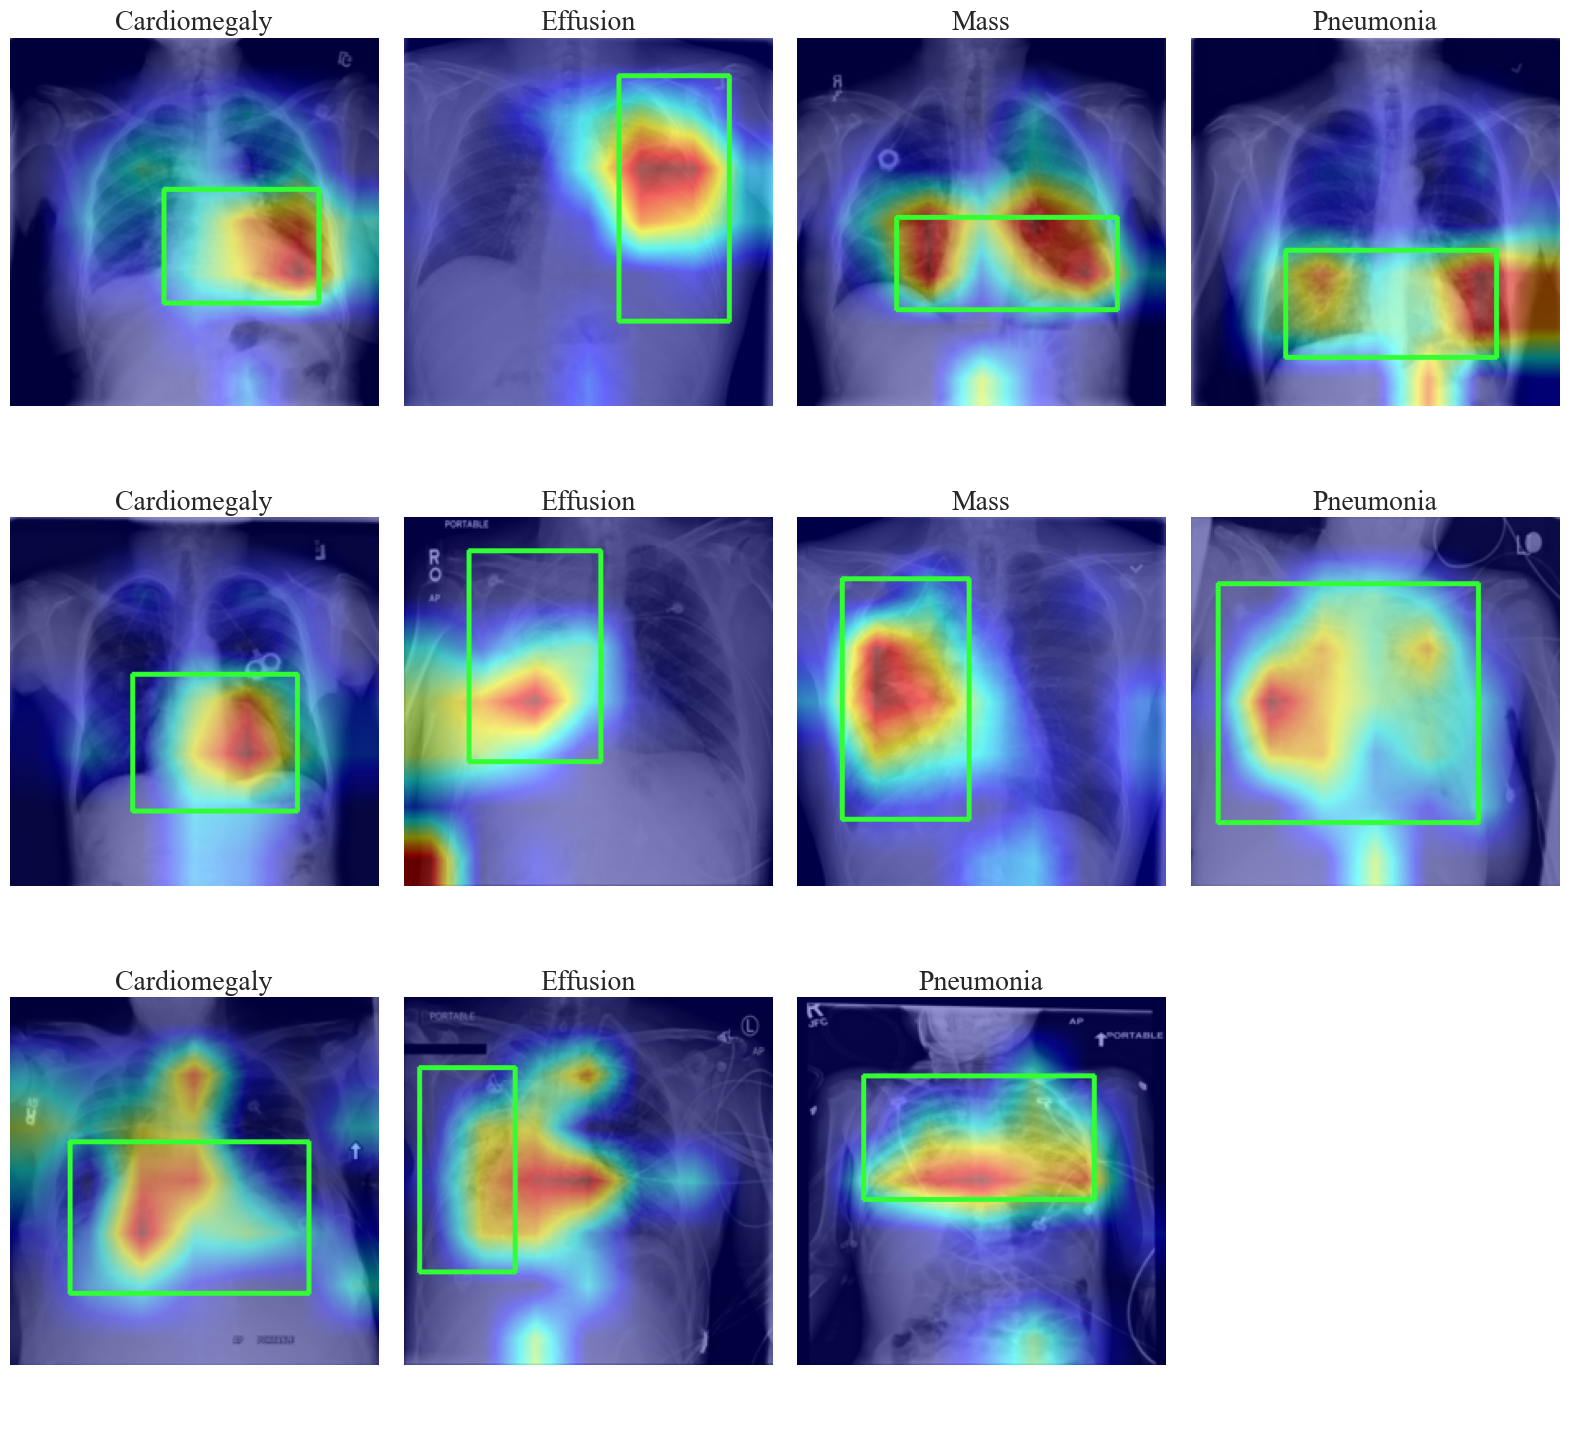

In [48]:
# -----------------------------
# 4) Visualize images where high Grad-CAM points are inside bbox
#    with class-balanced selection
# -----------------------------
TOP_PERCENTILE = 70             # top CAM intensity to define "high" points
MIN_INSIDE_RATIO = 0.40         # at least 40% of high points inside bbox
REQUIRE_PEAK_INSIDE = False     # also require global CAM peak inside bbox

selected_examples = []
used_images = set()
selected_per_class = {d: 0 for d in DISEASES}

# Shuffle candidates within each class for fairer sampling across diseases
class_to_rows = {}
for disease in DISEASES:
    class_rows = one_bbox_per_image[one_bbox_per_image['Finding Label'] == disease].copy()
    if len(class_rows) > 0:
        class_rows = class_rows.sample(frac=1.0, random_state=42).reset_index(drop=True)
    class_to_rows[disease] = class_rows

class_ptr = {d: 0 for d in DISEASES}


def build_example_if_valid(row, top_percentile, min_inside_ratio, require_peak_inside):
    image_name = row['Image Index']
    target_label = row['Finding Label']
    image_path = test_name_to_path.get(image_name)

    if image_path is None:
        return None

    image_bgr = cv2.imread(image_path)
    if image_bgr is None:
        return None

    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    input_tensor = base_transform(image=image_rgb)['image'].unsqueeze(0).to(device)
    class_idx = DISEASES.index(target_label)

    with torch.no_grad():
        pred_logit = swin(input_tensor)[0, class_idx].item()
    pred_prob = 1 / (1 + np.exp(-pred_logit))

    grayscale_cam = cam_extractor(
        input_tensor=input_tensor,
        targets=[ClassifierOutputTarget(class_idx)]
    )[0]

    # Coordinate scaling and Bounding Box logic
    h_img, w_img = image_rgb.shape[:2]
    x, y, w_box, h_box = float(row['x']), float(row['y']), float(row['w']), float(row['h'])

    # NIH bbox can occasionally be defined in a 1024x1024 reference frame
    if (x + w_box > w_img) or (y + h_box > h_img):
        sx, sy = w_img / 1024.0, h_img / 1024.0
        x, y, w_box, h_box = x * sx, y * sy, w_box * sx, h_box * sy

    x1, y1 = int(max(0, x)), int(max(0, y))
    x2, y2 = int(min(w_img - 1, x + w_box)), int(min(h_img - 1, y + h_box))

    if x2 <= x1 or y2 <= y1:
        return None

    # Build high-CAM mask
    high_thr = np.percentile(grayscale_cam, top_percentile)
    high_mask = grayscale_cam >= high_thr
    if high_mask.sum() == 0:
        return None

    # Map bbox to CAM resolution for overlap calculation
    cam_h, cam_w = grayscale_cam.shape
    sx_cam, sy_cam = cam_w / w_img, cam_h / h_img

    cx1 = int(np.clip(np.floor(x1 * sx_cam), 0, cam_w - 1))
    cy1 = int(np.clip(np.floor(y1 * sy_cam), 0, cam_h - 1))
    cx2 = int(np.clip(np.ceil(x2 * sx_cam), 0, cam_w - 1))
    cy2 = int(np.clip(np.ceil(y2 * sy_cam), 0, cam_h - 1))

    bbox_mask = np.zeros_like(high_mask, dtype=bool)
    bbox_mask[cy1:cy2 + 1, cx1:cx2 + 1] = True

    inside_ratio = (high_mask & bbox_mask).sum() / high_mask.sum()
    peak_y, peak_x = np.unravel_index(np.argmax(grayscale_cam), grayscale_cam.shape)
    peak_inside = bool(bbox_mask[peak_y, peak_x])

    is_valid = inside_ratio >= min_inside_ratio
    if require_peak_inside:
        is_valid = is_valid and peak_inside
    if not is_valid:
        return None

    image_float = image_rgb.astype(np.float32) / 255.0
    cam_overlay = show_cam_on_image(image_float, grayscale_cam, use_rgb=True, image_weight=0.55)
    cv2.rectangle(cam_overlay, (x1, y1), (x2, y2), (50, 255, 50), 2)

    return {
        'Image Index': image_name,
        'Finding Label': target_label,
        'x': x,
        'y': y,
        'w': w_box,
        'h': h_box,
        'pred_prob': pred_prob,
        'inside_ratio': inside_ratio,
        'peak_inside': peak_inside,
        'cam_overlay': cam_overlay
    }


# Multi-pass strategy: first strict and highly diverse, then relaxed to fill quota.
selection_passes = [
    {'top_percentile': TOP_PERCENTILE, 'min_inside_ratio': MIN_INSIDE_RATIO, 'require_peak_inside': REQUIRE_PEAK_INSIDE, 'max_per_class': 1},
    {'top_percentile': max(55, TOP_PERCENTILE - 10), 'min_inside_ratio': max(0.25, MIN_INSIDE_RATIO - 0.10), 'require_peak_inside': False, 'max_per_class': 2},
    {'top_percentile': max(45, TOP_PERCENTILE - 20), 'min_inside_ratio': max(0.15, MIN_INSIDE_RATIO - 0.20), 'require_peak_inside': False, 'max_per_class': 3},
]

for cfg in selection_passes:
    if len(selected_examples) >= N_IMAGES:
        break

    made_progress = True
    while made_progress and len(selected_examples) < N_IMAGES:
        made_progress = False

        for disease in DISEASES:
            if len(selected_examples) >= N_IMAGES:
                break

            if selected_per_class[disease] >= cfg['max_per_class']:
                continue

            rows = class_to_rows[disease]
            while class_ptr[disease] < len(rows):
                row = rows.iloc[class_ptr[disease]]
                class_ptr[disease] += 1

                if row['Image Index'] in used_images:
                    continue

                example = build_example_if_valid(
                    row,
                    top_percentile=cfg['top_percentile'],
                    min_inside_ratio=cfg['min_inside_ratio'],
                    require_peak_inside=cfg['require_peak_inside']
                )
                if example is None:
                    continue

                selected_examples.append(example)
                used_images.add(example['Image Index'])
                selected_per_class[disease] += 1
                made_progress = True
                break

if len(selected_examples) == 0:
    raise ValueError('No images met the Grad-CAM-inside-bbox criterion. Try lowering MIN_INSIDE_RATIO or TOP_PERCENTILE.')

if len(selected_examples) < N_IMAGES:
    print(f'Warning: only found {len(selected_examples)} images matching CAM-inside-bbox criteria (target={N_IMAGES}).')

selected_df = pd.DataFrame([{k: v for k, v in ex.items() if k != 'cam_overlay'} for ex in selected_examples])
display(selected_df[['Image Index', 'Finding Label', 'inside_ratio', 'peak_inside', 'pred_prob']])
print('Class distribution in selected examples:')
print(selected_df['Finding Label'].value_counts())

n_to_plot = len(selected_examples)
cols = 4
rows = int(np.ceil(n_to_plot / cols))

fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 5 * rows))
axes = np.array(axes).reshape(-1)

for i, ex in enumerate(selected_examples):
    ax = axes[i]
    ax.imshow(ex['cam_overlay'])
    ax.set_title(f"{ex['Finding Label']}")
    ax.axis('off')

for j in range(n_to_plot, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()